In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras torch torch_geometric torch_sparse torch_scatter torch_cluster networkx tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00
  Created wheel for torch_sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1261475 sha256=81a4bfa2a56edda44fcf944433d5e2d0554930a4dc45bd18985e2beb1f2774a0
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4ecc924a63b82f6949dda484b6321eac6f2
  Created wheel for torch_scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=677289 sha256=3dd4e54c19b7d98fc9b3562b382ee8b1972c7eea2b4d289cd0b1d95a4983ddc9
  Stored in direc

In [2]:
import os
import random
import numpy as np
import torch
import tensorflow as tf

SEED = 12

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

os.environ['PYTHONHASHSEED'] = str(SEED)

print("Reproducibility setup complete!")

Reproducibility setup complete!


In [3]:
import pandas as pd

# Load the CSV
df = pd.read_csv("/content/3_Companies_OHLCV.csv", index_col=0)

# Show the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Check info about columns and data types
print("\nDataset info:")
print(df.info())


selected_companies = ['AAPL', 'MSFT', 'NVDA']
columns_to_keep = []

for comp in selected_companies:
    for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
        column_name = f"{comp}_{col}"
        if column_name in df.columns:
            columns_to_keep.append(column_name)

# Create a new dataframe with only the selected columns
df_selected = df[columns_to_keep]

print("\nSelected 3 companies OHLCV data:")
print(df_selected.head())

First 5 rows of the dataset:
            AAPL_('Close', 'AAPL')  AAPL_('High', 'AAPL')  \
Date                                                        
2015-01-02               24.261049              24.729272   
2015-01-05               23.577574              24.110150   
2015-01-06               23.579792              23.839422   
2015-01-07               23.910431              24.010288   
2015-01-08               24.829123              24.886819   

            AAPL_('Low', 'AAPL')  AAPL_('Open', 'AAPL')  \
Date                                                      
2015-01-02             23.821673              24.718176   
2015-01-05             23.391173              24.030263   
2015-01-06             23.218083              23.641926   
2015-01-07             23.677428              23.788382   
2015-01-08             24.121240              24.238852   

            AAPL_('Volume', 'AAPL')  MSFT_('Close', 'MSFT')  \
Date                                                          
201

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [5]:
#Load & Clean Data

df = pd.read_csv("/content/3_Companies_OHLCV.csv", index_col=0)

# Clean column names
clean_cols = []
for col in df.columns:
    if "_(" in col:
        # Convert e.g., "AAPL_('Close', 'AAPL')" -> "AAPL_Close"
        col_clean = col.split(",")[0].replace("(", "").replace("'", "").strip() + "_" + \
                    col.split(",")[1].replace(")", "").replace("'", "").strip()
        clean_cols.append(col_clean)
    else:
        clean_cols.append(col)
df.columns = clean_cols

# Show first rows and info
print(df.head())
print(df.info())

# Close prices
close_cols = [col for col in df.columns if 'Close' in col]
data = df[close_cols].values
print(f"Using columns: {close_cols}")

            AAPL_Close_AAPL  AAPL_High_AAPL  AAPL_Low_AAPL  AAPL_Open_AAPL  \
Date                                                                         
2015-01-02        24.261049       24.729272      23.821673       24.718176   
2015-01-05        23.577574       24.110150      23.391173       24.030263   
2015-01-06        23.579792       23.839422      23.218083       23.641926   
2015-01-07        23.910431       24.010288      23.677428       23.788382   
2015-01-08        24.829123       24.886819      24.121240       24.238852   

            AAPL_Volume_AAPL  MSFT_Close_MSFT  MSFT_High_MSFT  MSFT_Low_MSFT  \
Date                                                                           
2015-01-02         212818400        39.933041       40.496681      39.745163   
2015-01-05         257142000        39.565834       39.907432      39.497512   
2015-01-06         263188400        38.985119       39.924518      38.891178   
2015-01-07         160423600        39.480431       3

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# Load and Clean Dataset

df = pd.read_csv("/content/3_Companies_OHLCV.csv", index_col=0)

# Clean column names
clean_cols = []
for col in df.columns:
    if isinstance(col, str) and "_(" in col:
        col_clean = col.split(",")[0].replace("(", "").replace("'", "").strip() + "_" + \
                    col.split(",")[1].replace(")", "").replace("'", "").strip()
        clean_cols.append(col_clean)
    else:
        clean_cols.append(col)
df.columns = clean_cols

# Fill missing values (forward + backward)
df = df.ffill().bfill()

# Print info
print("Full dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Full dataset loaded successfully!
Shape: (2718, 15)
            AAPL_Close_AAPL  AAPL_High_AAPL  AAPL_Low_AAPL  AAPL_Open_AAPL  \
Date                                                                         
2015-01-02        24.261049       24.729272      23.821673       24.718176   
2015-01-05        23.577574       24.110150      23.391173       24.030263   
2015-01-06        23.579792       23.839422      23.218083       23.641926   
2015-01-07        23.910431       24.010288      23.677428       23.788382   
2015-01-08        24.829123       24.886819      24.121240       24.238852   

            AAPL_Volume_AAPL  MSFT_Close_MSFT  MSFT_High_MSFT  MSFT_Low_MSFT  \
Date                                                                           
2015-01-02         212818400        39.933041       40.496681      39.745163   
2015-01-05         257142000        39.565834       39.907432      39.497512   
2015-01-06         263188400        38.985119       39.924518      38.891178   
2

In [7]:
from sklearn.preprocessing import MinMaxScaler
import torch
import numpy as np


# Scale the full dataset
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)


# Create sequences
sequence_length = 30  # use past 30 days
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

# Train-Test Split
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to Torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float)
y_train_t = torch.tensor(y_train, dtype=torch.float)
X_test_t  = torch.tensor(X_test, dtype=torch.float)
y_test_t  = torch.tensor(y_test, dtype=torch.float)

# Print summary
print("Data ready for model training")
print(f"Train shape: X={X_train_t.shape}, y={y_train_t.shape}")
print(f"Test  shape: X={X_test_t.shape}, y={y_test_t.shape}")

Data ready for model training
Train shape: X=torch.Size([2150, 30, 15]), y=torch.Size([2150, 15])
Test  shape: X=torch.Size([538, 30, 15]), y=torch.Size([538, 15])


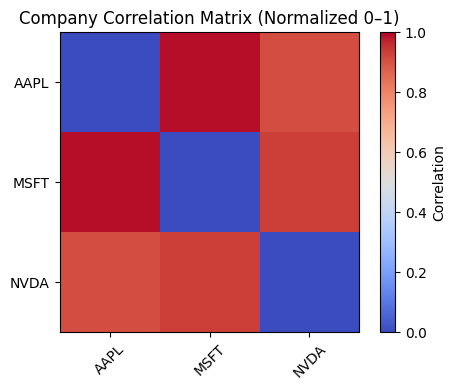

GCN edge matrix ready
Edge Index shape: torch.Size([2, 6])
Edge Weight shape: torch.Size([6])


In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt

company_names = ["AAPL", "MSFT", "NVDA"]

close_prices = df[
    ['AAPL_Close_AAPL',
     'MSFT_Close_MSFT',
     'NVDA_Close_NVDA']
].values

corr_matrix = np.corrcoef(close_prices.T)

corr_matrix = (corr_matrix + 1) / 2

np.fill_diagonal(corr_matrix, 0)

plt.figure(figsize=(5, 4))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(range(len(company_names)), company_names, rotation=45)
plt.yticks(range(len(company_names)), company_names)

plt.title('Company Correlation Matrix (Normalized 0–1)')
plt.tight_layout()
plt.show()

threshold = 0.5

edge_index = torch.tensor(
    np.array(np.where(corr_matrix > threshold)),
    dtype=torch.long
)

edge_weight = torch.tensor(
    corr_matrix[np.where(corr_matrix > threshold)],
    dtype=torch.float
)

print("GCN edge matrix ready")
print("Edge Index shape:", edge_index.shape)
print("Edge Weight shape:", edge_weight.shape)

In [9]:
def set_seed(seed=12):
    import os
    import random
    import numpy as np
    import torch
    import tensorflow as tf

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Random seed reset to {seed}")


In [10]:
set_seed(12)

Random seed reset to 12


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# GCN-LSTM Hybrid Model
class GCN_LSTM(nn.Module):
    def __init__(self, n_features, gcn_hidden=256, lstm_hidden=256):
        super(GCN_LSTM, self).__init__()
        self.gcn1 = GCNConv(n_features, gcn_hidden)
        self.lstm = nn.LSTM(gcn_hidden, lstm_hidden, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, n_features)

    def forward(self, x, edge_index, edge_weight):
        B, T, F_ = x.shape                      # Batch, Time, Features
        x = x.reshape(B*T, F_)                  # combine batch & time for GCN
        x = F.relu(self.gcn1(x, edge_index, edge_weight))
        x = x.reshape(B, T, -1)                 # reshape back for LSTM
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])            # last timestep output
        return out

# Initialize model
n_features = X_train_t.shape[2]  # from your tensor
model = GCN_LSTM(n_features=n_features)


# Optimizer & Loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("Model ready for training!")
print(f"Input features: {n_features}")
print(model)

Model ready for training!
Input features: 15
GCN_LSTM(
  (gcn1): GCNConv(15, 256)
  (lstm): LSTM(256, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=15, bias=True)
)


In [12]:
epochs = 1000
patience = 50
min_delta = 1e-4

best_loss = float("inf")
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_t, edge_index, edge_weight)

    # Loss
    loss = criterion(outputs, y_train_t)

    # Backward
    loss.backward()
    optimizer.step()

    # Early stopping
    if loss.item() < best_loss - min_delta:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch+1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

Epoch 1, Loss: 0.061721
Epoch 50, Loss: 0.001358
Epoch 100, Loss: 0.000948
Epoch 150, Loss: 0.000817
Early stopping at epoch 164


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t, edge_index, edge_weight)

y_true = y_test_t.numpy()
y_pred_np = y_pred.numpy()

mse  = mean_squared_error(y_true, y_pred_np)
mae  = mean_absolute_error(y_true, y_pred_np)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred_np)

print("GCN + LSTM Performance on Test Set (ALL FEATURES):")
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# store
gcn_lstm_mse_full  = mse
gcn_lstm_mae_full  = mae
gcn_lstm_rmse_full = rmse
gcn_lstm_r2_full   = r2


GCN + LSTM Performance on Test Set (ALL FEATURES):
MSE  : 0.003688
MAE  : 0.041455
RMSE : 0.060733
R²   : 0.587750


GCN + LSTM Hybrid Performance on Close Price (AAPL + MSFT + NVDA):
   MSE  : 0.0045
   RMSE : 0.0672
   MAE  : 0.0443
   R²   : 0.8593



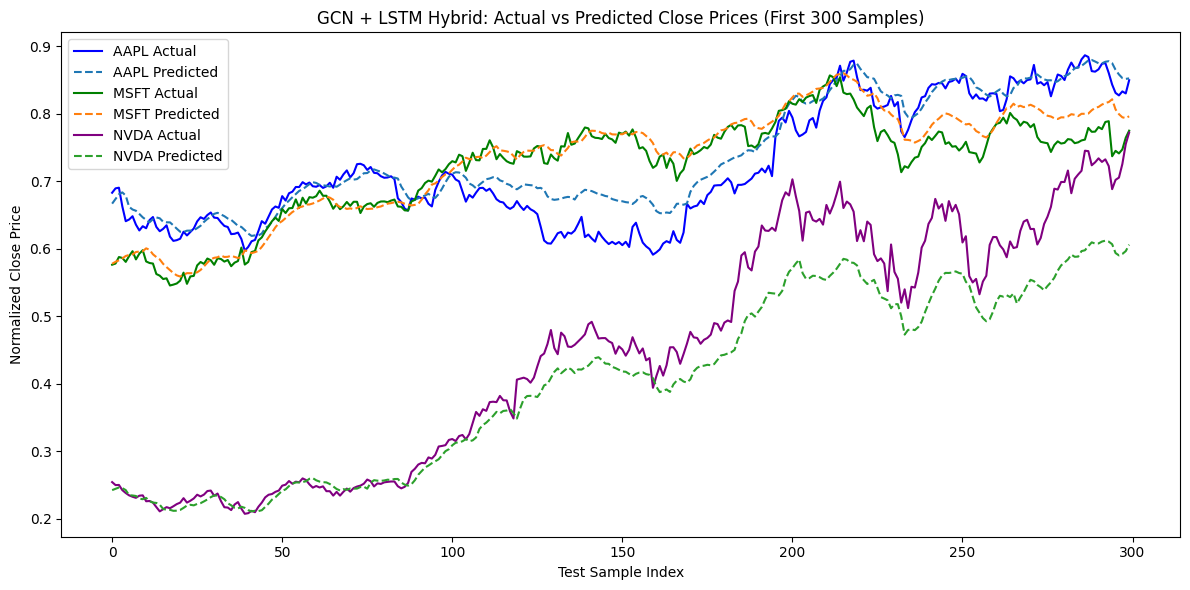

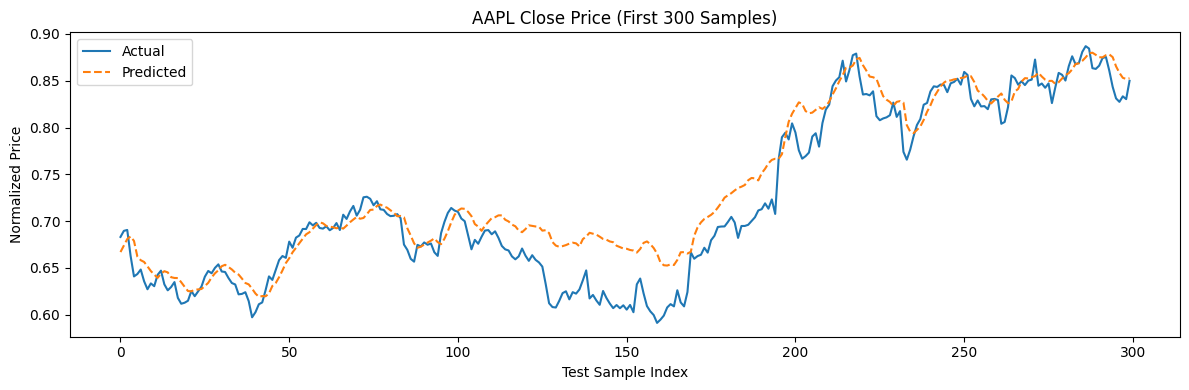

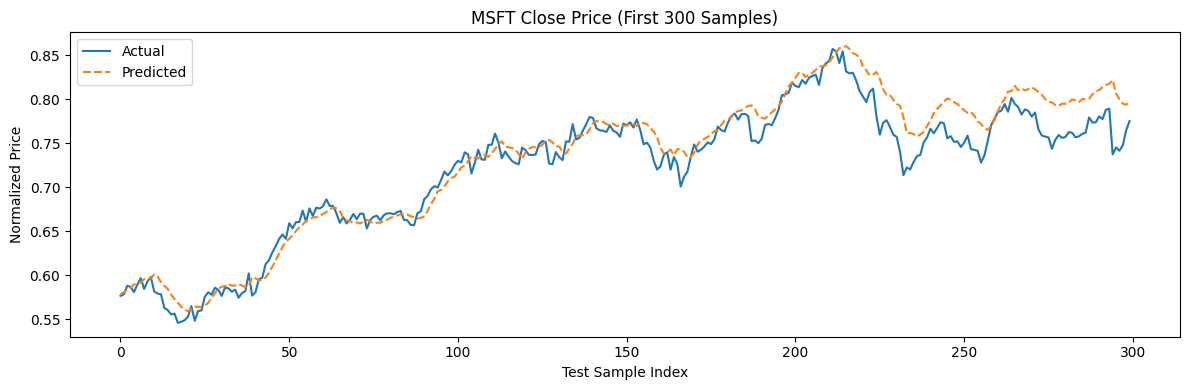

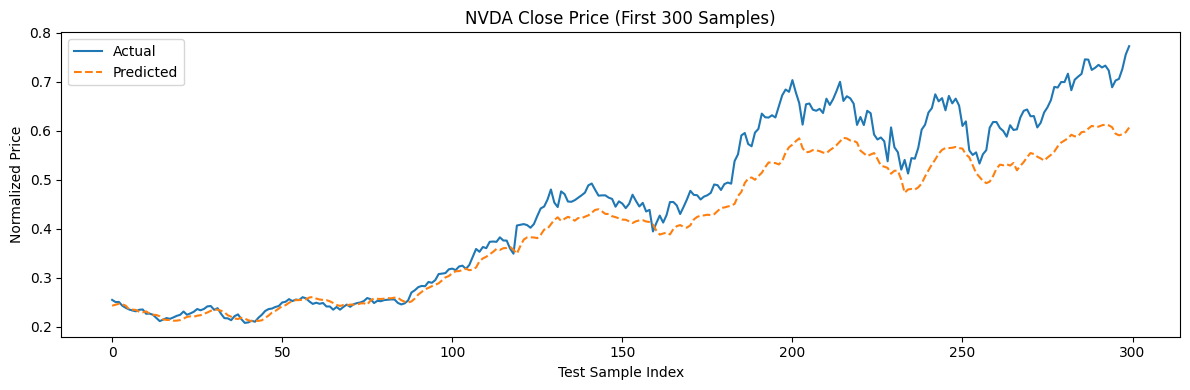

In [14]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    pred_hybrid = model(X_test_t, edge_index, edge_weight)

close_indices = [
    df.columns.get_loc('AAPL_Close_AAPL'),
    df.columns.get_loc('MSFT_Close_MSFT'),
    df.columns.get_loc('NVDA_Close_NVDA')
]

y_test_np      = y_test_t.numpy()[:, close_indices]
pred_hybrid_np = pred_hybrid.numpy()[:, close_indices]

def evaluate_model(y_true, y_pred, model_name="Model"):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"{model_name} Performance on Close Price (AAPL + MSFT + NVDA):")
    print(f"   MSE  : {mse:.4f}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}\n")

    return mse, rmse, mae, r2

mse_hybrid, rmse_hybrid, mae_hybrid, r2_hybrid = evaluate_model(
    y_test_np, pred_hybrid_np, "GCN + LSTM Hybrid"
)

gcn_lstm_mse_close  = mse_hybrid
gcn_lstm_rmse_close = rmse_hybrid
gcn_lstm_mae_close  = mae_hybrid
gcn_lstm_r2_close   = r2_hybrid

N_PLOT = 300

plt.figure(figsize=(12, 6))

plt.plot(y_test_np[:N_PLOT, 0], label="AAPL Actual", color="blue")
plt.plot(pred_hybrid_np[:N_PLOT, 0], label="AAPL Predicted", linestyle="--")

plt.plot(y_test_np[:N_PLOT, 1], label="MSFT Actual", color="green")
plt.plot(pred_hybrid_np[:N_PLOT, 1], label="MSFT Predicted", linestyle="--")

plt.plot(y_test_np[:N_PLOT, 2], label="NVDA Actual", color="purple")
plt.plot(pred_hybrid_np[:N_PLOT, 2], label="NVDA Predicted", linestyle="--")

plt.title("GCN + LSTM Hybrid: Actual vs Predicted Close Prices (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y_test_np[:N_PLOT, 0], label="Actual")
plt.plot(pred_hybrid_np[:N_PLOT, 0], label="Predicted", linestyle="--")
plt.title("AAPL Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y_test_np[:N_PLOT, 1], label="Actual")
plt.plot(pred_hybrid_np[:N_PLOT, 1], label="Predicted", linestyle="--")
plt.title("MSFT Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y_test_np[:N_PLOT, 2], label="Actual")
plt.plot(pred_hybrid_np[:N_PLOT, 2], label="Predicted", linestyle="--")
plt.title("NVDA Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
set_seed(12)

Random seed reset to 12


In [16]:
import torch
import torch.nn as nn

# LSTM Only Model
class LSTM_ONLY(nn.Module):
    def __init__(self, n_features, lstm_hidden=256):
        super(LSTM_ONLY, self).__init__()
        self.lstm = nn.LSTM(n_features, lstm_hidden, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, n_features)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [17]:

n_features = X_train_t.shape[2]

model = LSTM_ONLY(n_features=n_features)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.MSELoss()

print("Model has been reset to LSTM_ONLY")

print(type(model))

print(model)



Model has been reset to LSTM_ONLY
<class '__main__.LSTM_ONLY'>
LSTM_ONLY(
  (lstm): LSTM(15, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=15, bias=True)
)


In [18]:
epochs = 1000
patience = 50
min_delta = 1e-4

best_loss = float("inf")
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_t)

    # Compute loss
    loss = criterion(outputs, y_train_t)

    # Backward pass
    loss.backward()
    optimizer.step()

    # Early stopping
    if loss.item() < best_loss - min_delta:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Print every 50 epochs
    if (epoch+1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 1/1000, Loss: 0.058927
Epoch 50/1000, Loss: 0.001660
Epoch 100/1000, Loss: 0.001464
Epoch 150/1000, Loss: 0.001269
Epoch 200/1000, Loss: 0.001114
Epoch 250/1000, Loss: 0.001005
Early stopping at epoch 293


In [19]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t)

y_true = y_test_t.numpy()
y_pred_np = y_pred.numpy()

mse  = mean_squared_error(y_true, y_pred_np)
mae  = mean_absolute_error(y_true, y_pred_np)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred_np)

print("LSTM Performance on Test Set (ALL FEATURES):")
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# store
lstm_mse_full  = mse
lstm_mae_full  = mae
lstm_rmse_full = rmse
lstm_r2_full   = r2


LSTM Performance on Test Set (ALL FEATURES):
MSE  : 0.015519
MAE  : 0.088749
RMSE : 0.124577
R²   : -0.308829



LSTM Performance on Close Price (AAPL + MSFT + NVDA):
MSE  : 0.018329
MAE  : 0.095834
RMSE : 0.135385
R²   : 0.403078


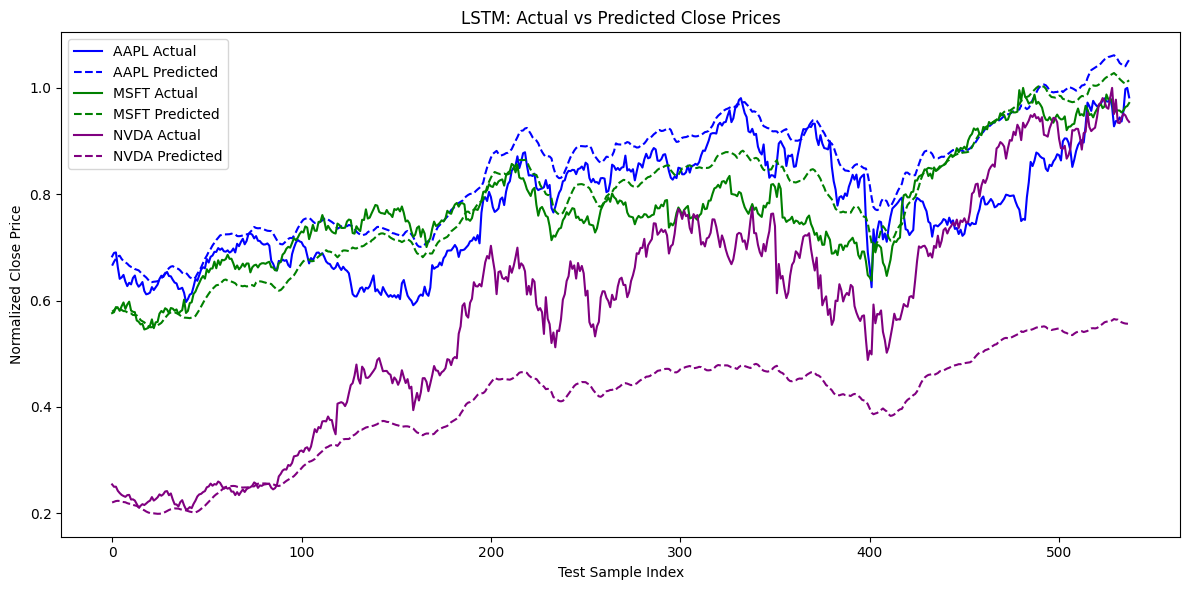

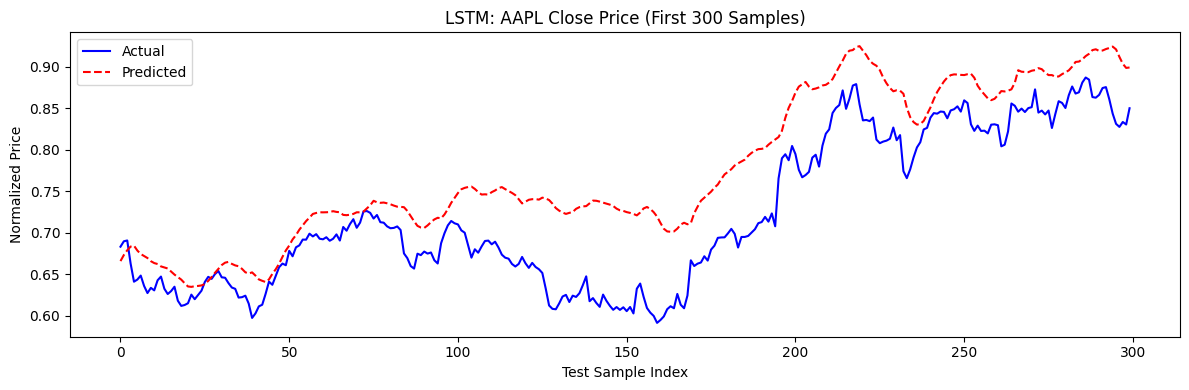

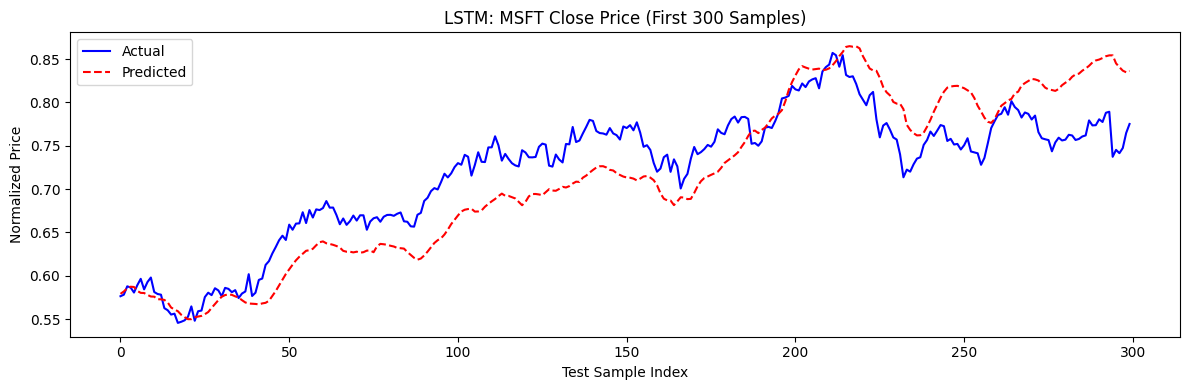

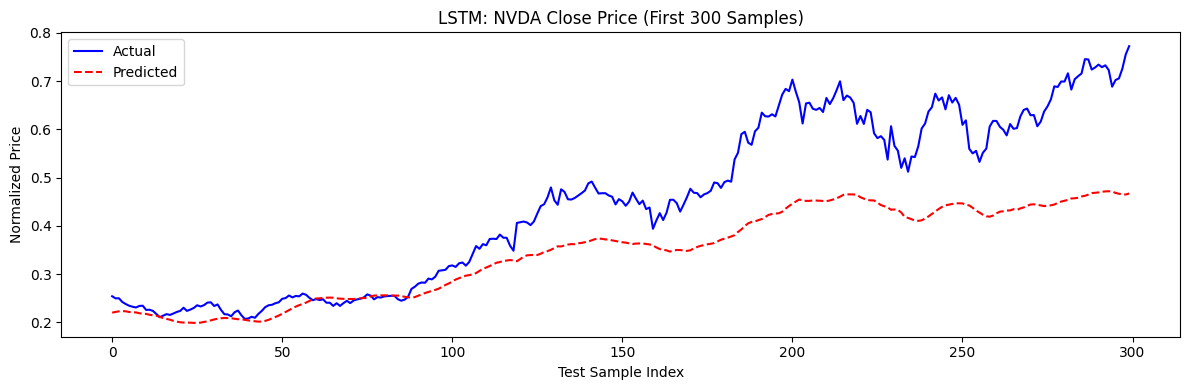

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t)

close_indices = [
    df.columns.get_loc('AAPL_Close_AAPL'),
    df.columns.get_loc('MSFT_Close_MSFT'),
    df.columns.get_loc('NVDA_Close_NVDA')
]

y_true_close = y_test_t.numpy()[:, close_indices]
y_pred_close = y_pred.numpy()[:, close_indices]

# ---- Metrics on CLOSE prices (averaged over companies) ----
mse_close  = mean_squared_error(y_true_close, y_pred_close)
mae_close  = mean_absolute_error(y_true_close, y_pred_close)
rmse_close = np.sqrt(mse_close)
r2_close   = r2_score(y_true_close, y_pred_close)

lstm_mse_close  = mse_close
lstm_mae_close  = mae_close
lstm_rmse_close = rmse_close
lstm_r2_close   = r2_close

print("\nLSTM Performance on Close Price (AAPL + MSFT + NVDA):")
print(f"MSE  : {mse_close:.6f}")
print(f"MAE  : {mae_close:.6f}")
print(f"RMSE : {rmse_close:.6f}")
print(f"R²   : {r2_close:.6f}")

N_PLOT = 300

plt.figure(figsize=(12, 6))

plt.plot(y_true_close[:, 0], label="AAPL Actual", color="blue")
plt.plot(y_pred_close[:, 0], label="AAPL Predicted", color="blue", linestyle="--")

plt.plot(y_true_close[:, 1], label="MSFT Actual", color="green")
plt.plot(y_pred_close[:, 1], label="MSFT Predicted", color="green", linestyle="--")

plt.plot(y_true_close[:, 2], label="NVDA Actual", color="purple")
plt.plot(y_pred_close[:, 2], label="NVDA Predicted", color="purple", linestyle="--")

plt.title("LSTM: Actual vs Predicted Close Prices")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.tight_layout()
plt.show()



# AAPL
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 0], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 0], label="Predicted", color="red", linestyle="--")
plt.title("LSTM: AAPL Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# MSFT
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 1], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 1], label="Predicted", color="red", linestyle="--")
plt.title("LSTM: MSFT Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# NVDA
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 2], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 2], label="Predicted", color="red", linestyle="--")
plt.title("LSTM: NVDA Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
set_seed(12)


Random seed reset to 12


In [22]:
import torch
import torch.nn as nn

# RNN Only Model
class RNN_ONLY(nn.Module):
    def __init__(self, n_features, rnn_hidden=256):
        super(RNN_ONLY, self).__init__()
        self.rnn = nn.RNN(n_features, rnn_hidden, batch_first=True)
        self.fc = nn.Linear(rnn_hidden, n_features)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

# Initialize model
n_features = X_train_t.shape[2]
model = RNN_ONLY(n_features=n_features)

# Optimizer & Loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("RNN model ready for training!")
print(model)

RNN model ready for training!
RNN_ONLY(
  (rnn): RNN(15, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=15, bias=True)
)


In [23]:
epochs = 1000
patience = 50
min_delta = 1e-4

best_loss = float("inf")
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_t)

    # Compute loss
    loss = criterion(outputs, y_train_t)

    # Backward pass
    loss.backward()
    optimizer.step()

    # Early stopping
    if loss.item() < best_loss - min_delta:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Print every 50 epochs
    if (epoch+1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 1/1000, Loss: 0.064779
Epoch 50/1000, Loss: 0.001430
Epoch 100/1000, Loss: 0.001075
Epoch 150/1000, Loss: 0.000903
Early stopping at epoch 186


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t)

y_true    = y_test_t.numpy()
y_pred_np = y_pred.numpy()

mse  = mean_squared_error(y_true, y_pred_np)
mae  = mean_absolute_error(y_true, y_pred_np)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred_np)

print("\nRNN Performance on Test Set:")
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# store
rnn_mse_full  = mse
rnn_mae_full  = mae
rnn_rmse_full = rmse
rnn_r2_full   = r2


RNN Performance on Test Set:
MSE  : 0.006675
MAE  : 0.058807
RMSE : 0.081702
R²   : -0.331910



RNN Performance on Close Price (AAPL + MSFT + NVDA):
MSE  : 0.003349
MAE  : 0.040958
RMSE : 0.057870
R²   : 0.882379


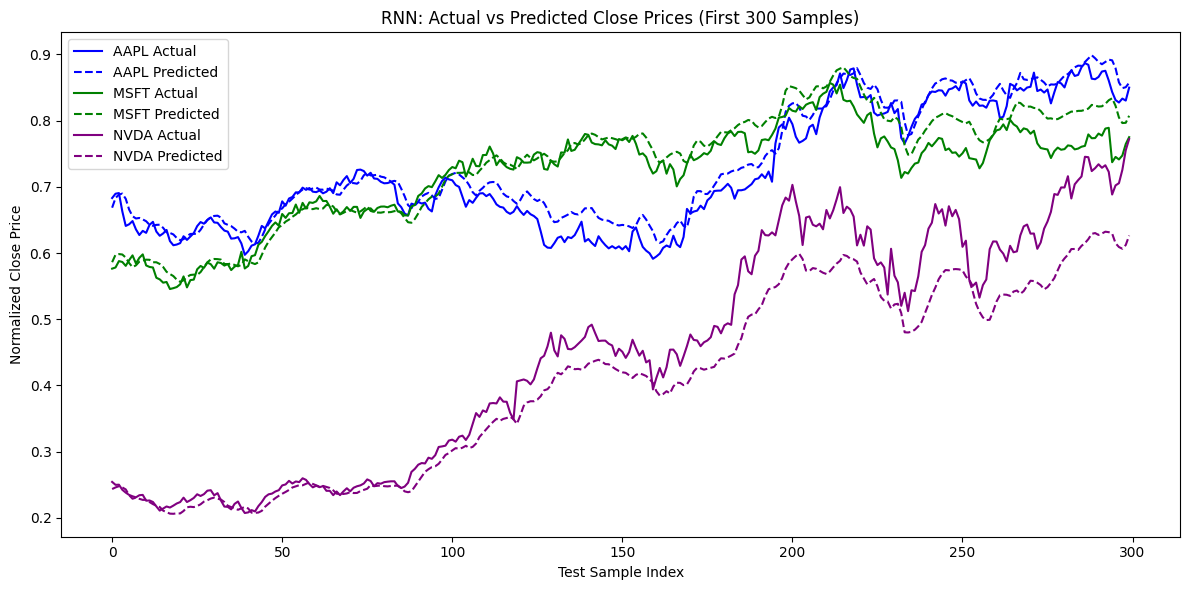

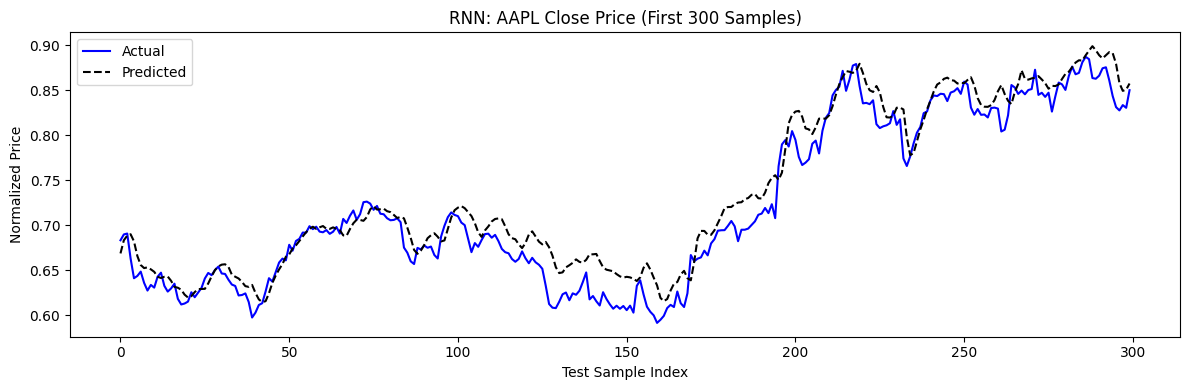

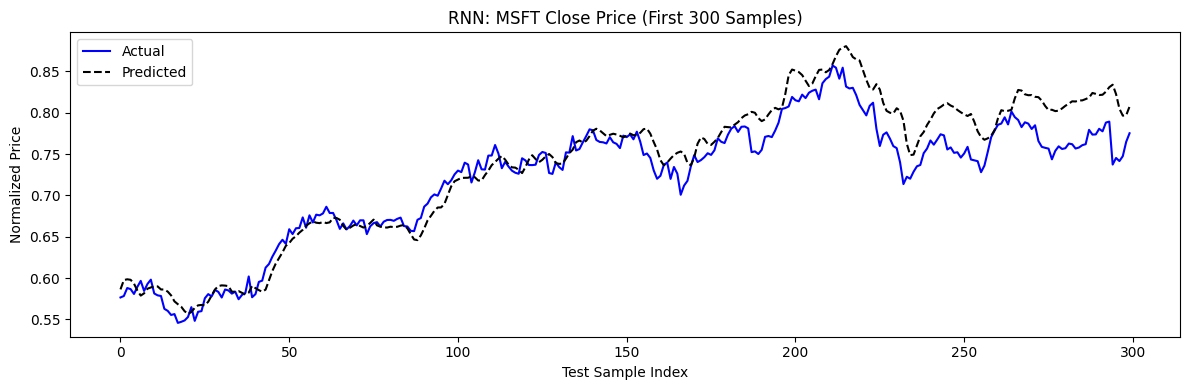

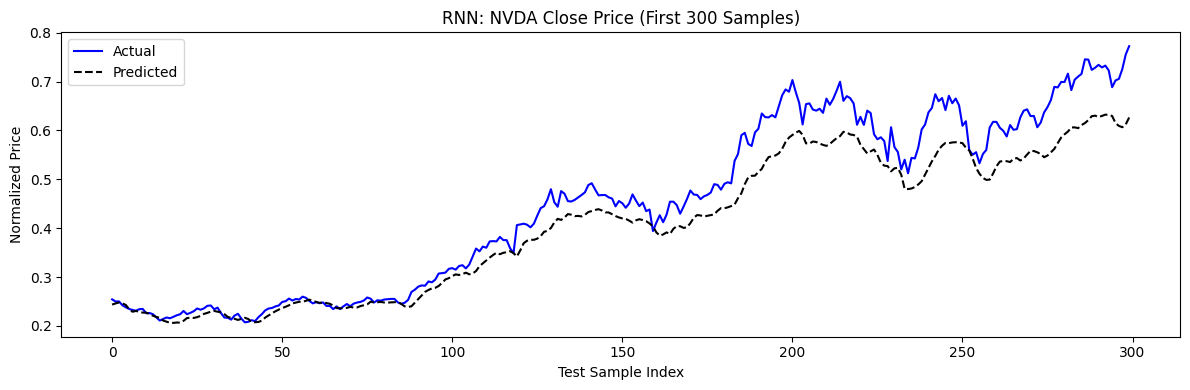

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t)

close_indices = [
    df.columns.get_loc('AAPL_Close_AAPL'),
    df.columns.get_loc('MSFT_Close_MSFT'),
    df.columns.get_loc('NVDA_Close_NVDA')
]

y_true_close = y_test_t.numpy()[:, close_indices]
y_pred_close = y_pred.numpy()[:, close_indices]

# ---- Metrics on CLOSE prices (averaged over companies) ----
mse_close  = mean_squared_error(y_true_close, y_pred_close)
mae_close  = mean_absolute_error(y_true_close, y_pred_close)
rmse_close = np.sqrt(mse_close)
r2_close   = r2_score(y_true_close, y_pred_close)

rnn_mse_close  = mse_close
rnn_mae_close  = mae_close
rnn_rmse_close = rmse_close
rnn_r2_close   = r2_close

print("\nRNN Performance on Close Price (AAPL + MSFT + NVDA):")
print(f"MSE  : {mse_close:.6f}")
print(f"MAE  : {mae_close:.6f}")
print(f"RMSE : {rmse_close:.6f}")
print(f"R²   : {r2_close:.6f}")

N_PLOT = 300

plt.figure(figsize=(12, 6))

plt.plot(y_true_close[:N_PLOT, 0], label="AAPL Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 0], label="AAPL Predicted", color="blue", linestyle="--")

plt.plot(y_true_close[:N_PLOT, 1], label="MSFT Actual", color="green")
plt.plot(y_pred_close[:N_PLOT, 1], label="MSFT Predicted", color="green", linestyle="--")

plt.plot(y_true_close[:N_PLOT, 2], label="NVDA Actual", color="purple")
plt.plot(y_pred_close[:N_PLOT, 2], label="NVDA Predicted", color="purple", linestyle="--")

plt.title("RNN: Actual vs Predicted Close Prices (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.tight_layout()
plt.show()


# AAPL
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 0], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 0], label="Predicted", color="black", linestyle="--")
plt.title("RNN: AAPL Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# MSFT
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 1], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 1], label="Predicted", color="black", linestyle="--")
plt.title("RNN: MSFT Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# NVDA
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 2], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 2], label="Predicted", color="black", linestyle="--")
plt.title("RNN: NVDA Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
set_seed(12)

Random seed reset to 12


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN_ONLY(nn.Module):
    def __init__(self, n_features, gcn_hidden=256):
        super(GCN_ONLY, self).__init__()
        self.gcn1 = GCNConv(n_features, gcn_hidden)
        self.fc = nn.Linear(gcn_hidden, n_features)

    def forward(self, x, edge_index, edge_weight):
        x = F.relu(self.gcn1(x, edge_index, edge_weight))
        out = self.fc(x)
        return out

B, T, F_ = X_train_t.shape
X_train_gcn = X_train_t.reshape(-1, F_)  # [B*T, F]
X_test_gcn  = X_test_t.reshape(-1, F_)
y_train_gcn = y_train_t.reshape(-1, F_)
y_test_gcn  = y_test_t.reshape(-1, F_)

n_features = F_
model = GCN_ONLY(n_features=n_features)

# Optimizer & Loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("GCN model ready for training ")
print(model)

GCN model ready for training 
GCN_ONLY(
  (gcn1): GCNConv(15, 256)
  (fc): Linear(in_features=256, out_features=15, bias=True)
)


In [28]:
epochs = 1000
patience = 50
min_delta = 1e-4

best_loss = float("inf")
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_t, edge_index, edge_weight)

    # ---- SAFETY CHECK ----
    # If output is [B, T, F], reduce to [B, F]
    if outputs.dim() == 3:
        outputs = outputs.mean(dim=1)

    # Loss (target is [B, F])
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    if loss.item() < best_loss - min_delta:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"[GCN] Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

[GCN] Epoch 1/1000, Loss: 0.057114
[GCN] Epoch 50/1000, Loss: 0.001778
[GCN] Epoch 100/1000, Loss: 0.001495
[GCN] Epoch 150/1000, Loss: 0.001374
Early stopping at epoch 189


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t, edge_index, edge_weight)

if y_pred.dim() == 3:
    y_pred = y_pred.mean(dim=1)

y_true    = y_test_t.numpy()      # shape [B, F]
y_pred_np = y_pred.numpy()        # shape [B, F]

# ---- Metrics ----
mse  = mean_squared_error(y_true, y_pred_np)
mae  = mean_absolute_error(y_true, y_pred_np)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred_np)



print("\nGCN Performance on Test Set:")
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# store
gcn_mse_full  = mse
gcn_mae_full  = mae
gcn_rmse_full = rmse
gcn_r2_full   = r2


GCN Performance on Test Set:
MSE  : 0.013750
MAE  : 0.087673
RMSE : 0.117260
R²   : -1.465612



GCN Performance on Close Price (AAPL + MSFT + NVDA):
MSE  : 0.008889
MAE  : 0.071654
RMSE : 0.094284
R²   : 0.637140


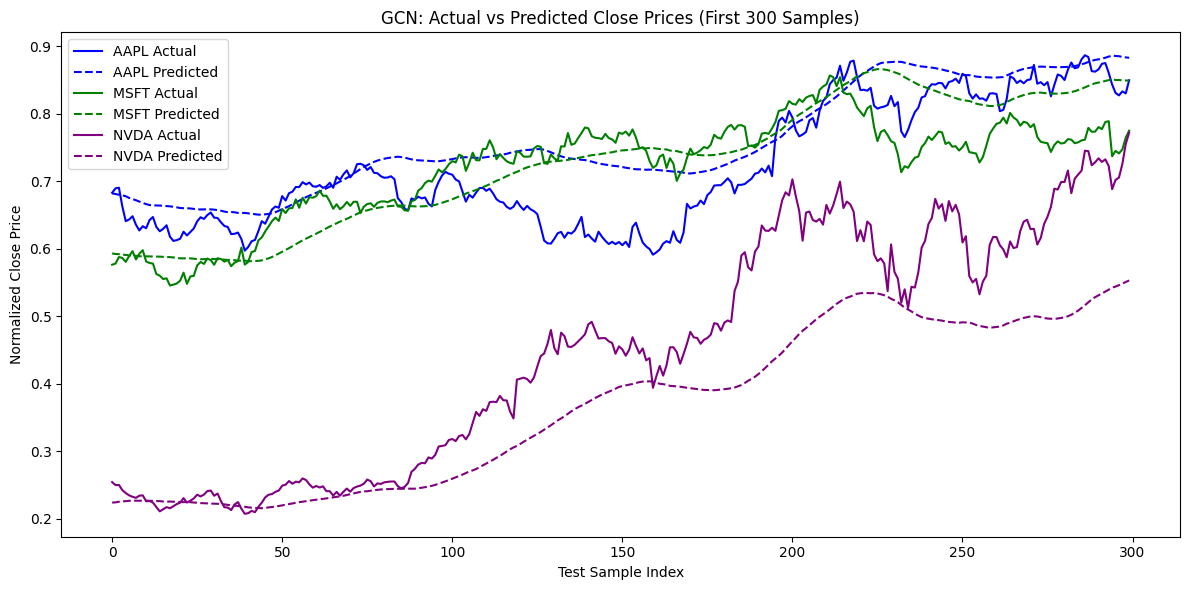

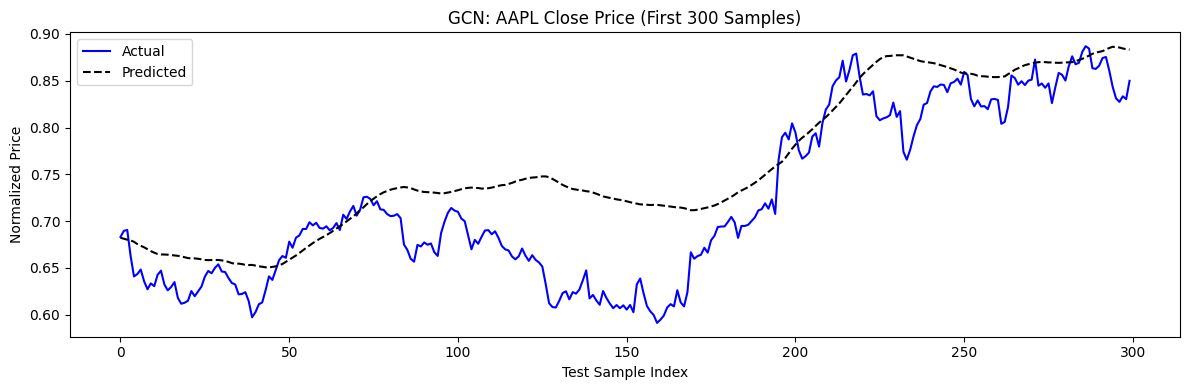

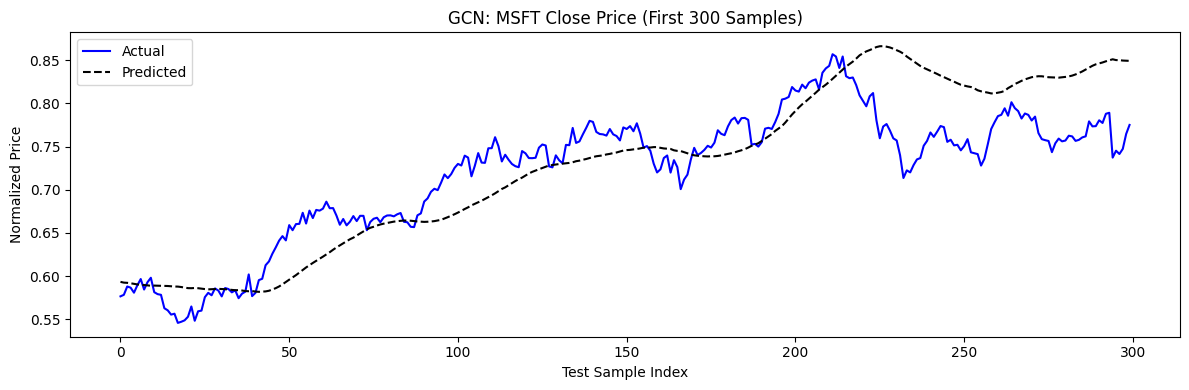

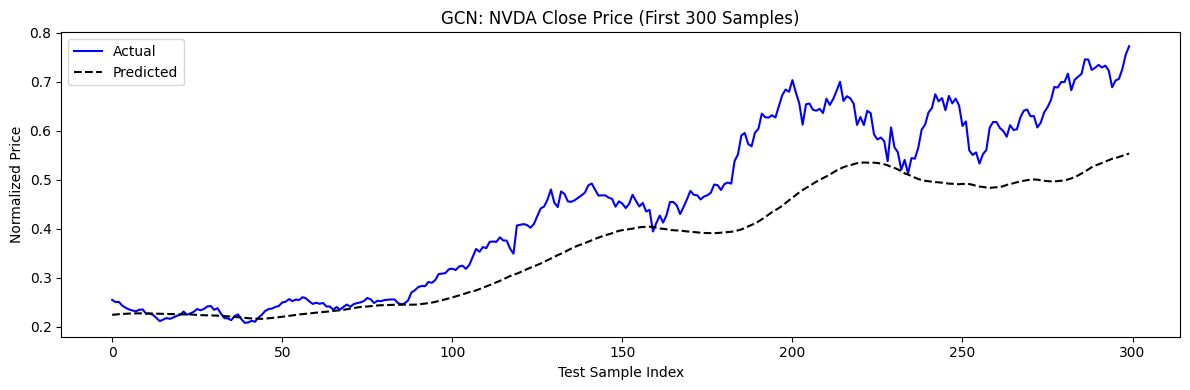

In [30]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t, edge_index, edge_weight)


if y_pred.dim() == 3:
    y_pred = y_pred.mean(dim=1)

close_indices = [
    df.columns.get_loc('AAPL_Close_AAPL'),
    df.columns.get_loc('MSFT_Close_MSFT'),
    df.columns.get_loc('NVDA_Close_NVDA')
]

y_true_close = y_test_t.numpy()[:, close_indices]
y_pred_close = y_pred.numpy()[:, close_indices]


mse_close  = mean_squared_error(y_true_close, y_pred_close)
mae_close  = mean_absolute_error(y_true_close, y_pred_close)
rmse_close = np.sqrt(mse_close)
r2_close   = r2_score(y_true_close, y_pred_close)

gcn_mse_close  = mse_close
gcn_mae_close  = mae_close
gcn_rmse_close = rmse_close
gcn_r2_close   = r2_close

print("\nGCN Performance on Close Price (AAPL + MSFT + NVDA):")
print(f"MSE  : {mse_close:.6f}")
print(f"MAE  : {mae_close:.6f}")
print(f"RMSE : {rmse_close:.6f}")
print(f"R²   : {r2_close:.6f}")


N_PLOT = 300


plt.figure(figsize=(12, 6))

plt.plot(y_true_close[:N_PLOT, 0], label="AAPL Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 0], label="AAPL Predicted", color="blue", linestyle="--")

plt.plot(y_true_close[:N_PLOT, 1], label="MSFT Actual", color="green")
plt.plot(y_pred_close[:N_PLOT, 1], label="MSFT Predicted", color="green", linestyle="--")

plt.plot(y_true_close[:N_PLOT, 2], label="NVDA Actual", color="purple")
plt.plot(y_pred_close[:N_PLOT, 2], label="NVDA Predicted", color="purple", linestyle="--")

plt.title("GCN: Actual vs Predicted Close Prices (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.tight_layout()
plt.show()


# AAPL
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 0], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 0], label="Predicted", color="black", linestyle="--")
plt.title("GCN: AAPL Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# MSFT
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 1], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 1], label="Predicted", color="black", linestyle="--")
plt.title("GCN: MSFT Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# NVDA
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 2], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 2], label="Predicted", color="black", linestyle="--")
plt.title("GCN: NVDA Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
set_seed(12)

Random seed reset to 12


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN_RNN(nn.Module):
    def __init__(self, n_features, gcn_hidden=256, rnn_hidden=256):
        super(GCN_RNN, self).__init__()

        self.gcn = GCNConv(n_features, gcn_hidden)
        self.rnn = nn.RNN(
            input_size=gcn_hidden,
            hidden_size=rnn_hidden,
            batch_first=True
        )
        self.fc = nn.Linear(rnn_hidden, n_features)

    def forward(self, x, edge_index, edge_weight):
        B, T, F_ = x.shape

        # ----- GCN -----
        x = x.reshape(B * T, F_)
        x = F.relu(self.gcn(x, edge_index, edge_weight))
        x = x.reshape(B, T, -1)

        # ----- RNN -----
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])

        return out


In [33]:
n_features = X_train_t.shape[2]
model = GCN_RNN(n_features=n_features)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(model)

GCN_RNN(
  (gcn): GCNConv(15, 256)
  (rnn): RNN(256, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=15, bias=True)
)


In [34]:
epochs = 1000
patience = 50
best_loss = float("inf")
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t, edge_index, edge_weight)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    if loss.item() < best_loss - 1e-4:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch+1) % 50 == 0 or epoch == 0:
        print(f"[GCN+RNN] Epoch {epoch+1}, Loss: {loss.item():.6f}")


[GCN+RNN] Epoch 1, Loss: 0.050148
[GCN+RNN] Epoch 50, Loss: 0.001091
[GCN+RNN] Epoch 100, Loss: 0.000785
Early stopping at epoch 124


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t, edge_index, edge_weight)

# ---- Full feature metrics ----
y_true = y_test_t.numpy()
y_pred_np = y_pred.numpy()

mse = mean_squared_error(y_true, y_pred_np)
mae = mean_absolute_error(y_true, y_pred_np)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred_np)

print("\nGCN + RNN Performance on Test Set (ALL FEATURES):")
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# store
gcn_rnn_mse_full  = mse
gcn_rnn_mae_full  = mae
gcn_rnn_rmse_full = rmse
gcn_rnn_r2_full   = r2


GCN + RNN Performance on Test Set (ALL FEATURES):
MSE  : 0.003607
MAE  : 0.041019
RMSE : 0.060062
R²   : 0.506734


GCN + RNN Performance on Close Price (AAPL + MSFT + NVDA):
   MSE  : 0.0037
   RMSE : 0.0608
   MAE  : 0.0392
   R²   : 0.8941



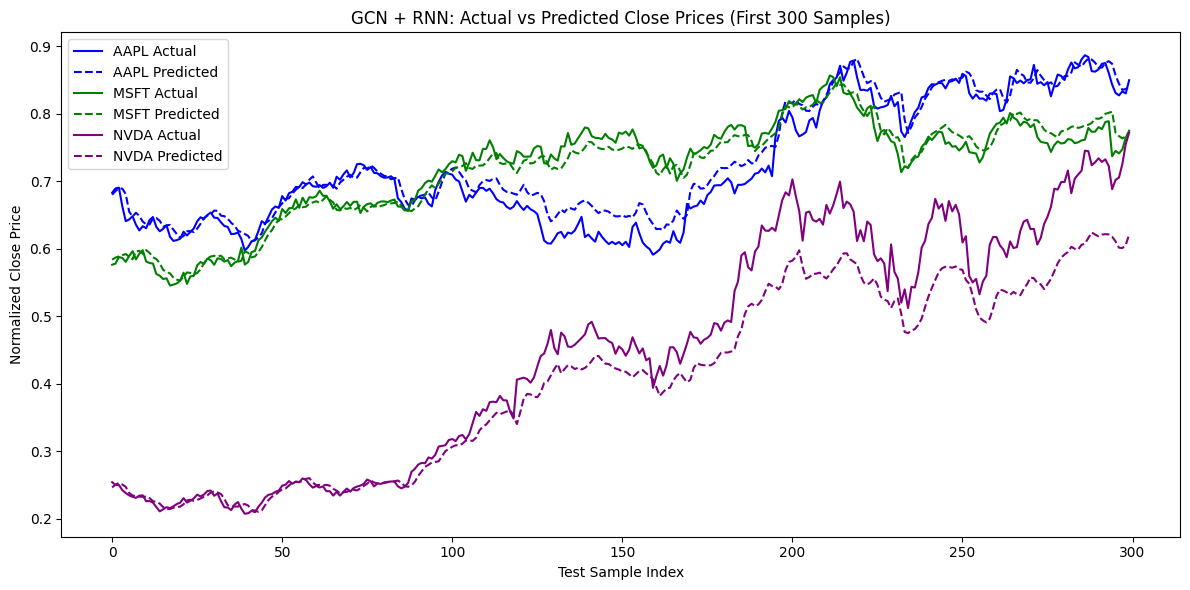

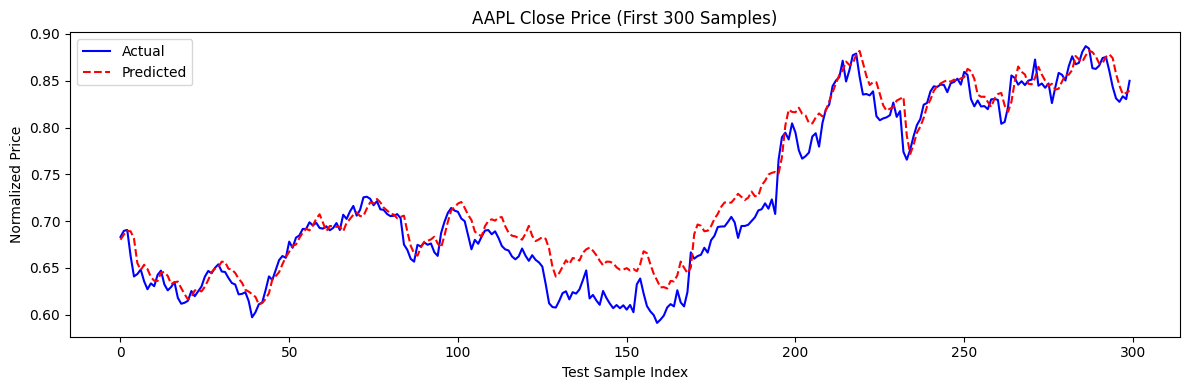

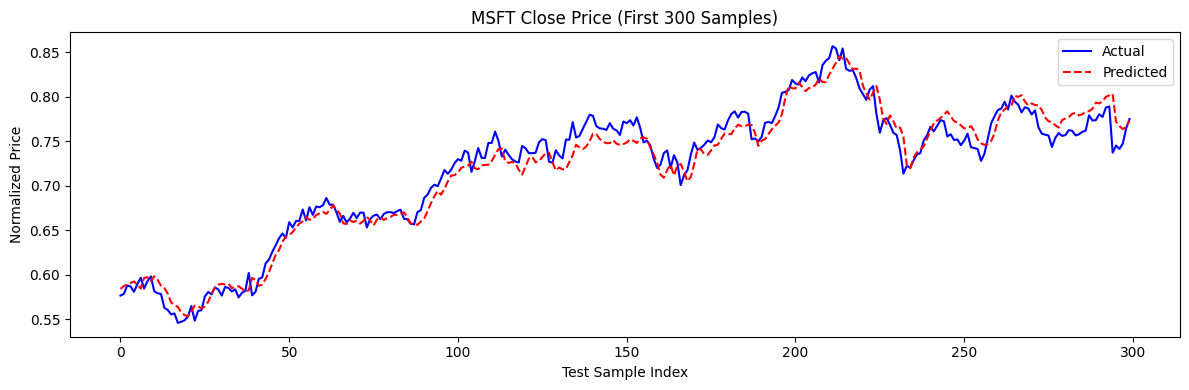

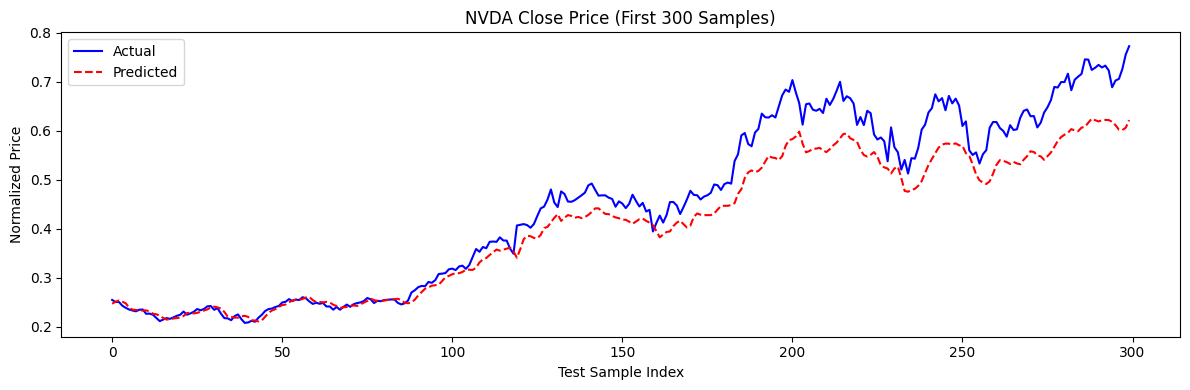

In [36]:

import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


model.eval()
with torch.no_grad():
    pred_hybrid = model(X_test_t, edge_index, edge_weight)


if pred_hybrid.dim() == 3:
    pred_hybrid = pred_hybrid.mean(dim=1)


close_indices = [
    df.columns.get_loc('AAPL_Close_AAPL'),
    df.columns.get_loc('MSFT_Close_MSFT'),
    df.columns.get_loc('NVDA_Close_NVDA')
]

y_test_np      = y_test_t.numpy()[:, close_indices]
pred_hybrid_np = pred_hybrid.numpy()[:, close_indices]

def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Compute and print MSE, RMSE, MAE, R² (averaged over companies)
    """
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"{model_name} Performance on Close Price (AAPL + MSFT + NVDA):")
    print(f"   MSE  : {mse:.4f}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}\n")

    return mse, rmse, mae, r2

mse_hybrid, rmse_hybrid, mae_hybrid, r2_hybrid = evaluate_model(
    y_test_np, pred_hybrid_np, "GCN + RNN"
)

gcn_rnn_mse_close  = mse_hybrid
gcn_rnn_rmse_close = rmse_hybrid
gcn_rnn_mae_close  = mae_hybrid
gcn_rnn_r2_close   = r2_hybrid


N_PLOT = 300

plt.figure(figsize=(12, 6))

plt.plot(y_test_np[:N_PLOT, 0], label="AAPL Actual", color="blue")
plt.plot(pred_hybrid_np[:N_PLOT, 0], label="AAPL Predicted", color="blue", linestyle="--")

plt.plot(y_test_np[:N_PLOT, 1], label="MSFT Actual", color="green")
plt.plot(pred_hybrid_np[:N_PLOT, 1], label="MSFT Predicted", color="green", linestyle="--")

plt.plot(y_test_np[:N_PLOT, 2], label="NVDA Actual", color="purple")
plt.plot(pred_hybrid_np[:N_PLOT, 2], label="NVDA Predicted", color="purple", linestyle="--")

plt.title("GCN + RNN: Actual vs Predicted Close Prices (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.tight_layout()
plt.show()


# AAPL
plt.figure(figsize=(12, 4))
plt.plot(y_test_np[:N_PLOT, 0], label="Actual", color="blue")
plt.plot(pred_hybrid_np[:N_PLOT, 0], label="Predicted", color="red", linestyle="--")
plt.title("AAPL Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# MSFT
plt.figure(figsize=(12, 4))
plt.plot(y_test_np[:N_PLOT, 1], label="Actual", color="blue")
plt.plot(pred_hybrid_np[:N_PLOT, 1], label="Predicted", color="red", linestyle="--")
plt.title("MSFT Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# NVDA
plt.figure(figsize=(12, 4))
plt.plot(y_test_np[:N_PLOT, 2], label="Actual", color="blue")
plt.plot(pred_hybrid_np[:N_PLOT, 2], label="Predicted", color="red", linestyle="--")
plt.title("NVDA Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
set_seed(12)

Random seed reset to 12


In [38]:
class LSTM_RNN(nn.Module):
    def __init__(self, n_features, lstm_hidden=256, rnn_hidden=256):
        super(LSTM_RNN, self).__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=lstm_hidden,
            batch_first=True
        )

        self.rnn = nn.RNN(
            input_size=lstm_hidden,
            hidden_size=rnn_hidden,
            batch_first=True
        )

        self.fc = nn.Linear(rnn_hidden, n_features)

    def forward(self, x):
        x, _ = self.lstm(x)
        x, _ = self.rnn(x)
        out = self.fc(x[:, -1, :])
        return out

In [39]:

n_features = X_train_t.shape[2]
model = LSTM_RNN(n_features=n_features)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(model)


LSTM_RNN(
  (lstm): LSTM(15, 256, batch_first=True)
  (rnn): RNN(256, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=15, bias=True)
)


In [40]:
epochs = 1000
patience = 50
best_loss = float("inf")
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    if loss.item() < best_loss - 1e-4:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch+1) % 50 == 0 or epoch == 0:
        print(f"[LSTM+RNN] Epoch {epoch+1}, Loss: {loss.item():.6f}")

[LSTM+RNN] Epoch 1, Loss: 0.071349
[LSTM+RNN] Epoch 50, Loss: 0.001648
[LSTM+RNN] Epoch 100, Loss: 0.001340
[LSTM+RNN] Epoch 150, Loss: 0.001129
[LSTM+RNN] Epoch 200, Loss: 0.001032
[LSTM+RNN] Epoch 250, Loss: 0.000916
Early stopping at epoch 262


In [41]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t)

# ---- Full feature metrics ----
y_true = y_test_t.numpy()
y_pred_np = y_pred.numpy()

mse = mean_squared_error(y_true, y_pred_np)
mae = mean_absolute_error(y_true, y_pred_np)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred_np)

print("\nLSTM + RNN Performance on Test Set (ALL FEATURES):")
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# store
lstm_rnn_mse_full  = mse
lstm_rnn_mae_full  = mae
lstm_rnn_rmse_full = rmse
lstm_rnn_r2_full   = r2



LSTM + RNN Performance on Test Set (ALL FEATURES):
MSE  : 0.006169
MAE  : 0.059813
RMSE : 0.078543
R²   : -0.077423



LSTM + RNN Performance on Close Prices (AAPL, MSFT, NVDA):
MSE  : 0.006012
MAE  : 0.059073
RMSE : 0.077535
R²   : 0.746643


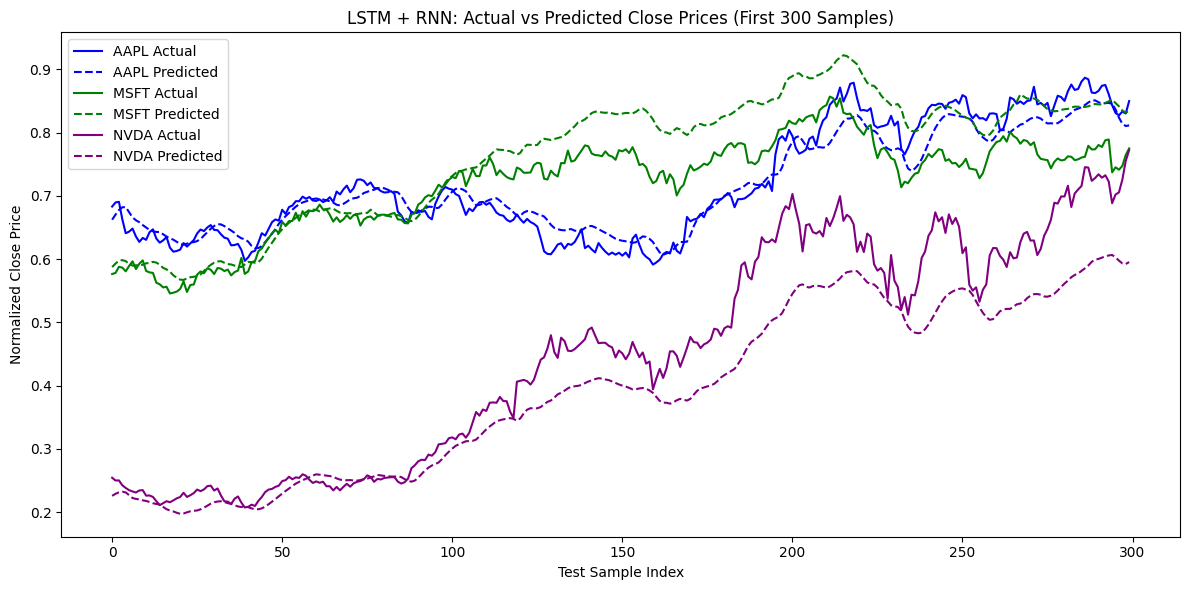

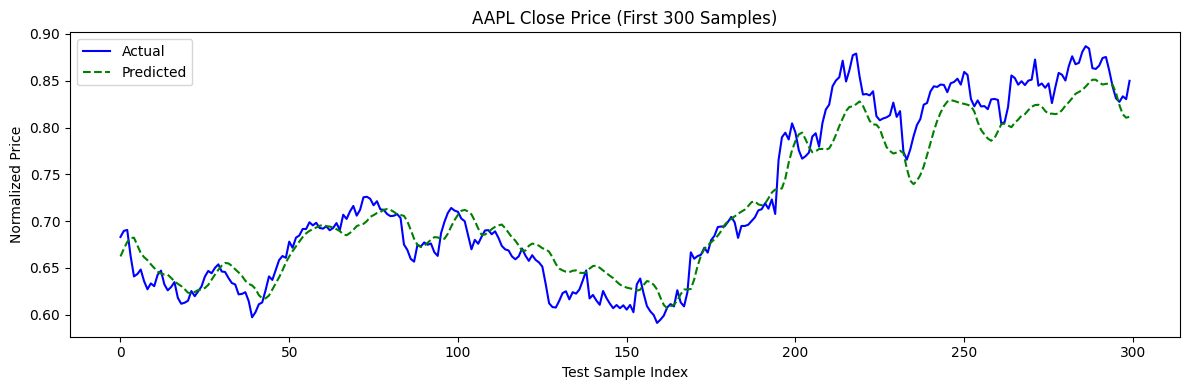

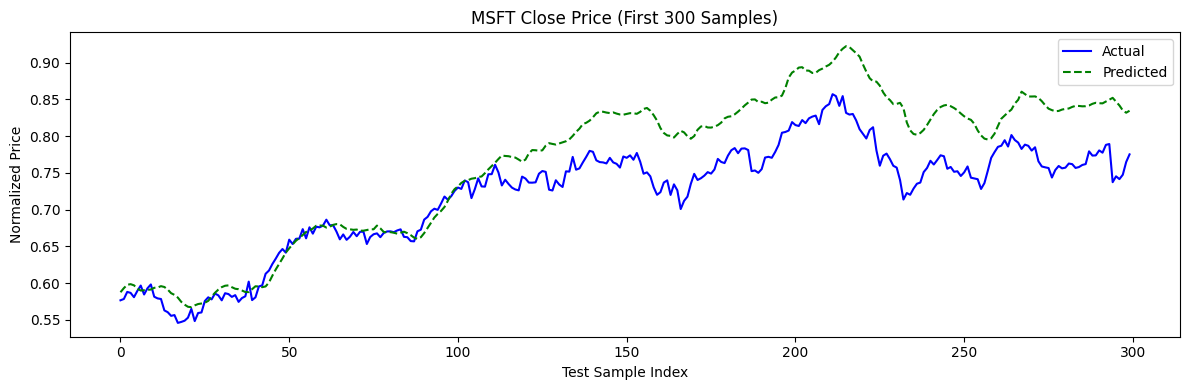

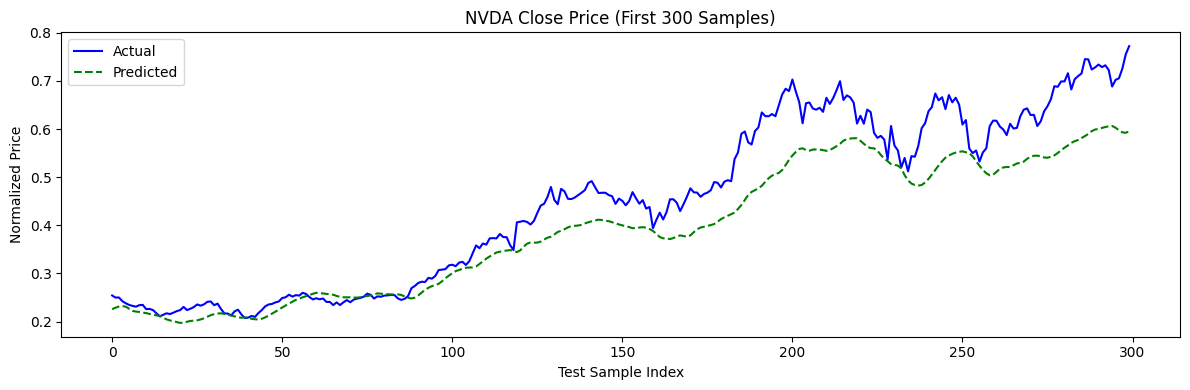

In [42]:

import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t)


if y_pred.dim() == 3:
    y_pred = y_pred.mean(dim=1)

AAPL_COL = 0
MSFT_COL = 5
NVDA_COL = 10

N_PLOT = 300

y_true_close = np.column_stack([
    y_test_t.numpy()[:, AAPL_COL],
    y_test_t.numpy()[:, MSFT_COL],
    y_test_t.numpy()[:, NVDA_COL],
])

y_pred_close = np.column_stack([
    y_pred.numpy()[:, AAPL_COL],
    y_pred.numpy()[:, MSFT_COL],
    y_pred.numpy()[:, NVDA_COL],
])

mse_c  = mean_squared_error(y_true_close, y_pred_close)
mae_c  = mean_absolute_error(y_true_close, y_pred_close)
rmse_c = np.sqrt(mse_c)
r2_c   = r2_score(y_true_close, y_pred_close)

lstm_rnn_mse_close  = mse_c
lstm_rnn_mae_close  = mae_c
lstm_rnn_rmse_close = rmse_c
lstm_rnn_r2_close   = r2_c

print("\nLSTM + RNN Performance on Close Prices (AAPL, MSFT, NVDA):")
print(f"MSE  : {mse_c:.6f}")
print(f"MAE  : {mae_c:.6f}")
print(f"RMSE : {rmse_c:.6f}")
print(f"R²   : {r2_c:.6f}")

plt.figure(figsize=(12, 6))

plt.plot(y_true_close[:N_PLOT, 0], label="AAPL Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 0], label="AAPL Predicted", color="blue", linestyle="--")

plt.plot(y_true_close[:N_PLOT, 1], label="MSFT Actual", color="green")
plt.plot(y_pred_close[:N_PLOT, 1], label="MSFT Predicted", color="green", linestyle="--")

plt.plot(y_true_close[:N_PLOT, 2], label="NVDA Actual", color="purple")
plt.plot(y_pred_close[:N_PLOT, 2], label="NVDA Predicted", color="purple", linestyle="--")

plt.title("LSTM + RNN: Actual vs Predicted Close Prices (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.tight_layout()
plt.show()


# AAPL
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 0], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 0], label="Predicted", color="green", linestyle="--")
plt.title("AAPL Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# MSFT
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 1], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 1], label="Predicted", color="green", linestyle="--")
plt.title("MSFT Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

# NVDA
plt.figure(figsize=(12, 4))
plt.plot(y_true_close[:N_PLOT, 2], label="Actual", color="blue")
plt.plot(y_pred_close[:N_PLOT, 2], label="Predicted", color="green", linestyle="--")
plt.title("NVDA Close Price (First 300 Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()


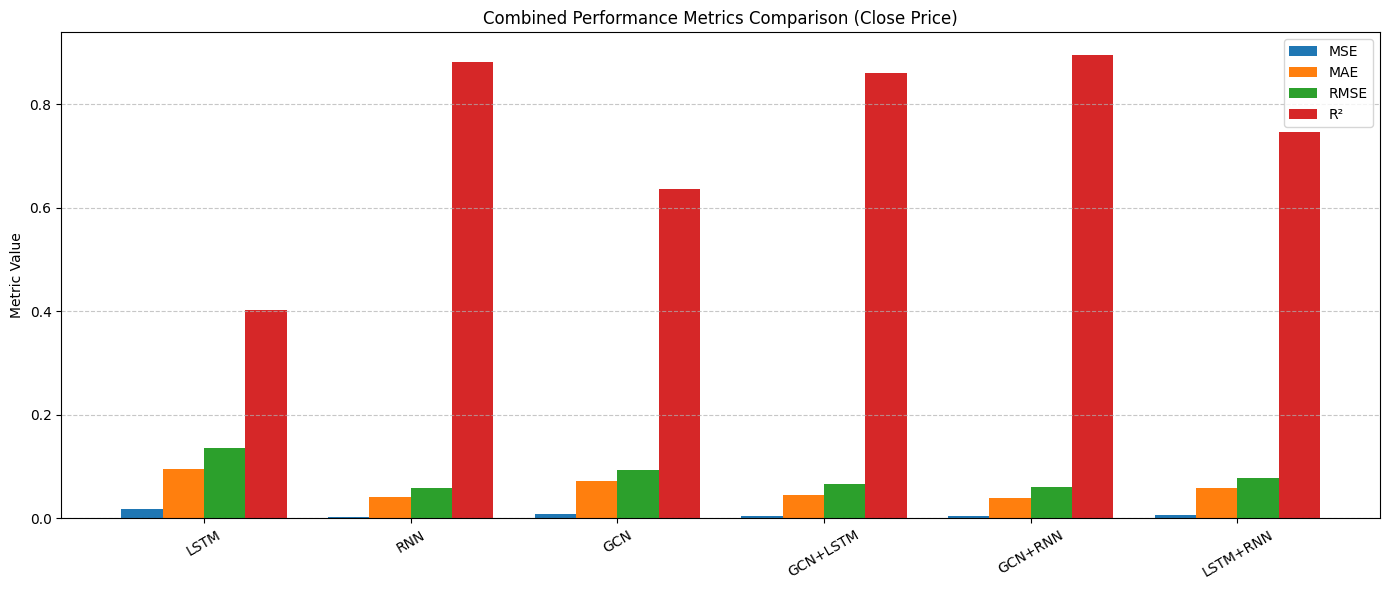

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe
df_metrics = pd.DataFrame({
    "Model": ["LSTM", "RNN", "GCN", "GCN+LSTM", "GCN+RNN", "LSTM+RNN"],
    "MSE": [
        lstm_mse_close, rnn_mse_close, gcn_mse_close,
        gcn_lstm_mse_close, gcn_rnn_mse_close, lstm_rnn_mse_close
    ],
    "MAE": [
        lstm_mae_close, rnn_mae_close, gcn_mae_close,
        gcn_lstm_mae_close, gcn_rnn_mae_close, lstm_rnn_mae_close
    ],
    "RMSE": [
        lstm_rmse_close, rnn_rmse_close, gcn_rmse_close,
        gcn_lstm_rmse_close, gcn_rnn_rmse_close, lstm_rnn_rmse_close
    ],
    "R2": [
        lstm_r2_close, rnn_r2_close, gcn_r2_close,
        gcn_lstm_r2_close, gcn_rnn_r2_close, lstm_rnn_r2_close
    ]
})

# Plot
x = np.arange(len(df_metrics))
width = 0.2

plt.figure(figsize=(14,6))
plt.bar(x - 1.5*width, df_metrics["MSE"],  width, label="MSE")
plt.bar(x - 0.5*width, df_metrics["MAE"],  width, label="MAE")
plt.bar(x + 0.5*width, df_metrics["RMSE"], width, label="RMSE")
plt.bar(x + 1.5*width, df_metrics["R2"],   width, label="R²")

plt.xticks(x, df_metrics["Model"], rotation=30)
plt.ylabel("Metric Value")
plt.title("Combined Performance Metrics Comparison (Close Price)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


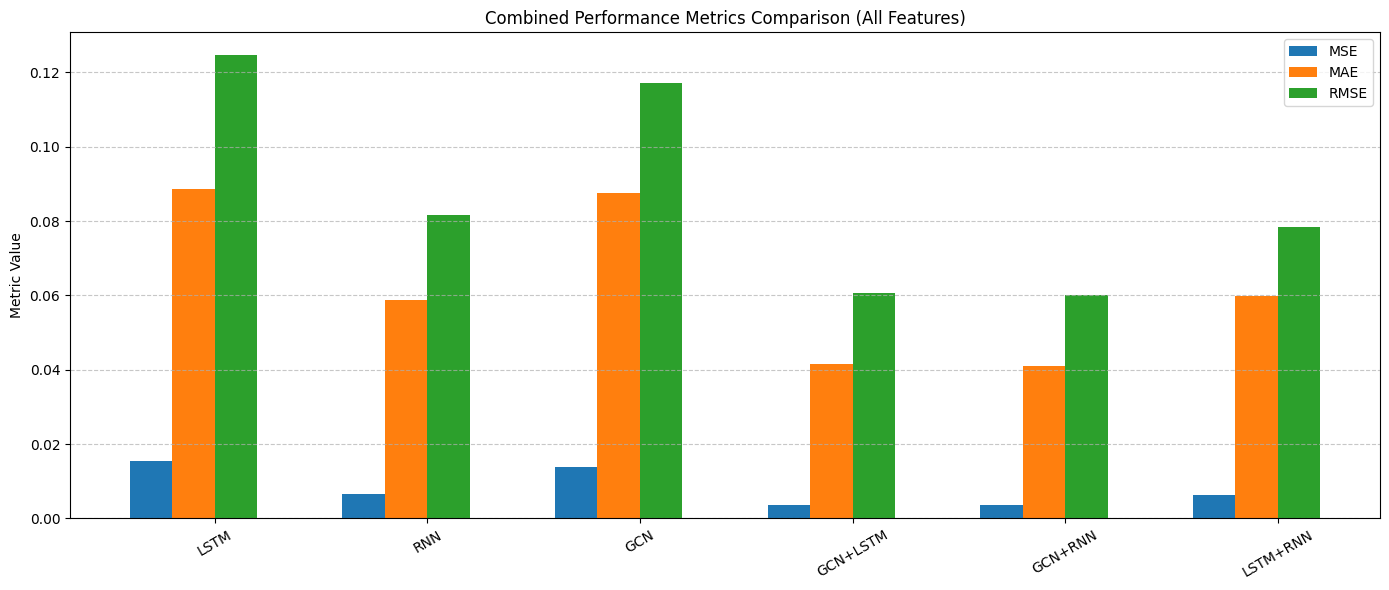

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_full = pd.DataFrame({
    "Model": ["LSTM", "RNN", "GCN", "GCN+LSTM", "GCN+RNN", "LSTM+RNN"],
    "MSE": [
        lstm_mse_full, rnn_mse_full, gcn_mse_full,
        gcn_lstm_mse_full, gcn_rnn_mse_full, lstm_rnn_mse_full
    ],
    "MAE": [
        lstm_mae_full, rnn_mae_full, gcn_mae_full,
        gcn_lstm_mae_full, gcn_rnn_mae_full, lstm_rnn_mae_full
    ],
    "RMSE": [
        lstm_rmse_full, rnn_rmse_full, gcn_rmse_full,
        gcn_lstm_rmse_full, gcn_rnn_rmse_full, lstm_rnn_rmse_full
    ],

})

x = np.arange(len(df_full))
width = 0.2

plt.figure(figsize=(14,6))
plt.bar(x - 1.5*width, df_full["MSE"],  width, label="MSE")
plt.bar(x - 0.5*width, df_full["MAE"],  width, label="MAE")
plt.bar(x + 0.5*width, df_full["RMSE"], width, label="RMSE")


plt.xticks(x, df_full["Model"], rotation=30)
plt.ylabel("Metric Value")
plt.title("Combined Performance Metrics Comparison (All Features)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
